# RECOVAR Demo

This demo consists of three parts:

1. **Continuous MSEED scoring with RECOVAR** read a real 3-component MiniSEED file with ObsPy, slide a 30 s window across it, and plot the earthquake score over time.
2. **Single window** score one earthquake window and one noise window on their own
3. **Labeled benchmark** run the classifier on a labeled test set and plot the ROC/AUC.

The MSEED data is `data/test.mseed`: 450 s of `KO.DKL..HH?` at 100 Hz around the M6.1 Bigadiç–Balıkesir 2025 earthquake. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import obspy
from scipy.signal import detrend

from recovar.representation_learning_models import RepresentationLearningMultipleAutoencoder
from recovar.classifier_models import ClassifierMultipleAutoencoder
from sklearn.metrics import roc_curve, roc_auc_score

2026-06-07 17:07:27.561859: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# MiniSEED data and sliding-window parameters
MSEED_PATH  = "data/test.mseed"
STEP_S      = 10.0   # sliding-window step
THRESHOLD   = 0.5    # detection threshold score ([0-1])

# RECOVAR preprocessing / model constants
WINDOW_SIZE  = 3000        # RECOVAR requires 30 s (3000-sample) windows
TRIM_SAMPLES = 500         # 5 s cut from each end to drop filter edge effects
FREQMIN, FREQMAX = 1.0, 20.0   # bandpass corners (Hz)

MODEL_PATH  = "models/representation_cross_covariances.h5"

Preprocess function used to preprocess MSEED files

In [ ]:
def preprocess(data, fs):
    """Demean, linear-detrend, and 1-20 Hz bandpass one channel (a 1-D array).
    """
    data = detrend(data - data.mean(), type="linear")
    freqs = np.fft.fftfreq(len(data), d=1.0 / fs)
    spectrum = np.fft.fft(data)
    spectrum[(np.abs(freqs) < FREQMIN) | (np.abs(freqs) > FREQMAX)] = 0
    return np.real(np.fft.ifft(spectrum)).astype(np.float32)

## Part 1: Continuous scoring

Read the file with ObsPy and plot it natively. Then preprocess each component,
slide a 30 s window across the trace, score every window, and plot the score over
time. It should rise sharply at the P arrival and decay through the coda.

3 Trace(s) in Stream:
KO.DKL..HHE | 2025-08-10T16:53:04.960000Z - 2025-08-10T17:00:34.950000Z | 100.0 Hz, 45000 samples
KO.DKL..HHN | 2025-08-10T16:53:04.960000Z - 2025-08-10T17:00:34.950000Z | 100.0 Hz, 45000 samples
KO.DKL..HHZ | 2025-08-10T16:53:04.960000Z - 2025-08-10T17:00:34.950000Z | 100.0 Hz, 45000 samples


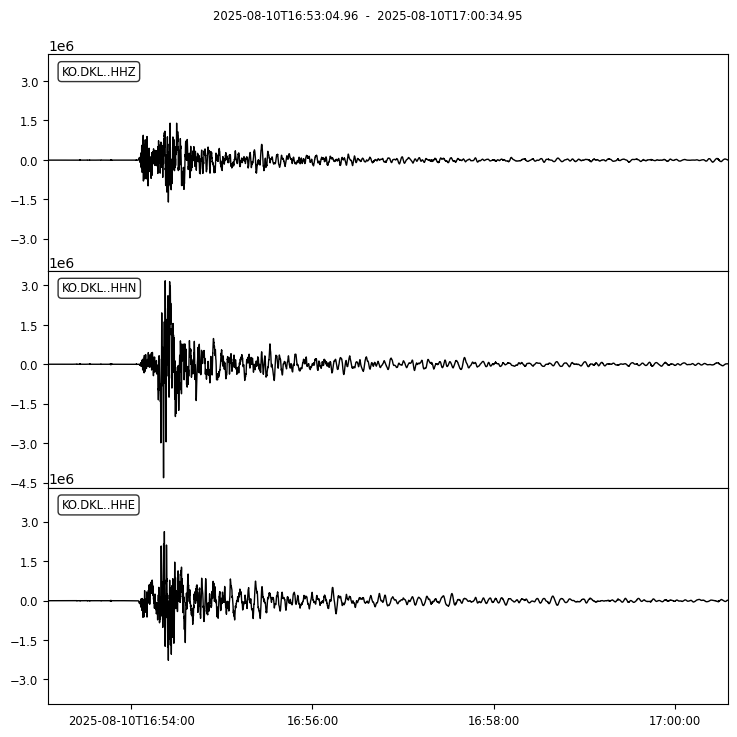

In [4]:
st = obspy.read(MSEED_PATH)
st.merge(method=1, fill_value=0)
print(st)

st.plot();

In [ ]:
# Pull the three components (RECOVAR expects channel order Z, N, E).
z = st.select(channel="*Z")[0]
n = st.select(channel="*N")[0]
e = st.select(channel="*E")[0]
t0 = z.stats.starttime
fs = z.stats.sampling_rate   # 100 Hz for this stream

# Preprocess each channel (demean + detrend + 1-20 Hz), then trim 5 s off each end to drop filter edge effects. 
# The first scored sample is at t0 + 5 s.
zp, nps, ep = [preprocess(tr.data.astype(np.float32), fs)[TRIM_SAMPLES:-TRIM_SAMPLES]
               for tr in (z, n, e)]
trim_start = t0 + TRIM_SAMPLES / fs

In [ ]:
# Build the RECOVAR classifier 
model = RepresentationLearningMultipleAutoencoder(
    name="rep_learning_autoencoder_ensemble", input_noise_std=1e-6, eps=1e-27)
model.compile()
model(np.zeros((1, WINDOW_SIZE, 3), dtype=np.float32))   # build, then load weights
model.load_weights(MODEL_PATH)

classifier = ClassifierMultipleAutoencoder(model)

In [ ]:
# Slide a 30 s (WINDOW_SIZE-sample) window with a STEP_S step.
step    = int(STEP_S * fs)
n_win   = (len(zp) - WINDOW_SIZE) // step + 1
windows = np.empty((n_win, WINDOW_SIZE, 3), dtype=np.float32)
times   = []
for i in range(n_win):
    s = i * step
    windows[i, :, 0] = zp[s:s + WINDOW_SIZE]
    windows[i, :, 1] = nps[s:s + WINDOW_SIZE]
    windows[i, :, 2] = ep[s:s + WINDOW_SIZE]
    times.append(float((trim_start + s / fs) - t0))   # window start, s from stream start

# Score every 30 s window in the stream in one call to the RECOVAR classifier (one score in [0, 1] per window).
scores = classifier(windows)

print(f"Scored {n_win} windows  (step={STEP_S:.0f}s, window={WINDOW_SIZE / fs:.0f}s)")
print(f"Score range: {scores.min():.4f} - {scores.max():.4f}")

Scored 42 windows  (step=10s, window=30s)
Score range: 0.0260 - 0.9370


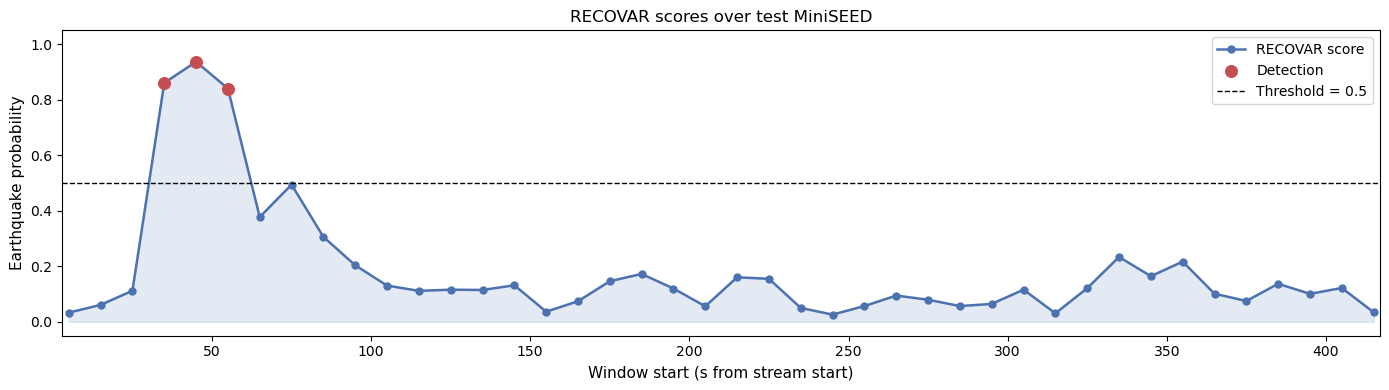

In [7]:
# Plot RECOVAR scores over the MSEED stream
times  = np.asarray(times)
scores = np.asarray(scores)
above  = scores >= THRESHOLD

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(times, scores, 0, color="#4C72B0", alpha=0.15)
ax.plot(times, scores, "-o", color="#4C72B0", linewidth=1.8, markersize=5, label="RECOVAR score")
ax.scatter(times[above], scores[above], s=70, color="#C44E52", zorder=3, label="Detection")
ax.axhline(THRESHOLD, color="k", linestyle="--", linewidth=1, label=f"Threshold = {THRESHOLD}")
ax.set_xlim(times[0] - 2, times[-1] + 2)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Window start (s from stream start)", fontsize=11)
ax.set_ylabel("Earthquake probability", fontsize=11)
ax.set_title("RECOVAR scores over test MiniSEED", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [8]:
# Print detections above the chosen threshold score 0.5 (can be tuned/changed)
detections = [(t, s) for t, s in zip(times, scores) if s >= THRESHOLD]
print(f"Detections above {THRESHOLD}: {len(detections)} window(s)\n")
if detections:
    print(f"  {'window start (s)':>16}  {'score':>6}  (UTC)")
    print("  " + "-" * 36)
    for t, s in detections:
        print(f"  {t:>16.1f}  {s:>6.4f}    ({(t0 + t).strftime('%H:%M:%S')})")

Detections above 0.5: 3 window(s)

  window start (s)   score  (UTC)
  ------------------------------------
              35.0  0.8605    (16:53:39)
              45.0  0.9370    (16:53:49)
              55.0  0.8403    (16:53:59)


## Part 2: Score a single window

Slice and score only one window (30 seconds) from the stream. 
Slice the window out of the stream Pad 5 s on each side so the bandpass filter's edge effects fall outside the part we keep.

### Scoring an Earthquake window

In [ ]:
# Pick the 30 s window to score. here we choose the window over the P arrival of the M6.1 earthquake 
t_eq = obspy.UTCDateTime("2025-08-10T16:53:51.96")

pad = TRIM_SAMPLES / fs
win_eq = st.slice(t_eq - pad, t_eq + WINDOW_SIZE / fs + pad)

# Preprocess
zw, nw, ew = [preprocess(win_eq.select(channel=f"*{c}")[0].data.astype(np.float32), fs)[TRIM_SAMPLES:TRIM_SAMPLES + WINDOW_SIZE]  for c in "ZNE"]

# Score the window 
waveform = np.stack([zw, nw, ew], axis=-1)[np.newaxis]   # (1, 3000, 3) the classifier wants a batch of (3000, 3) windows, so add a batch axis
score_eq = float(classifier(waveform)[0])

print(f"Earthquake window starting {t_eq}")
print(f"RECOVAR earthquake probability: {score_eq:.4f}")

Earthquake window starting 2025-08-10T16:53:51.960000Z
RECOVAR earthquake probability: 0.9645


RECOVAR score = 0.965  (earthquake)


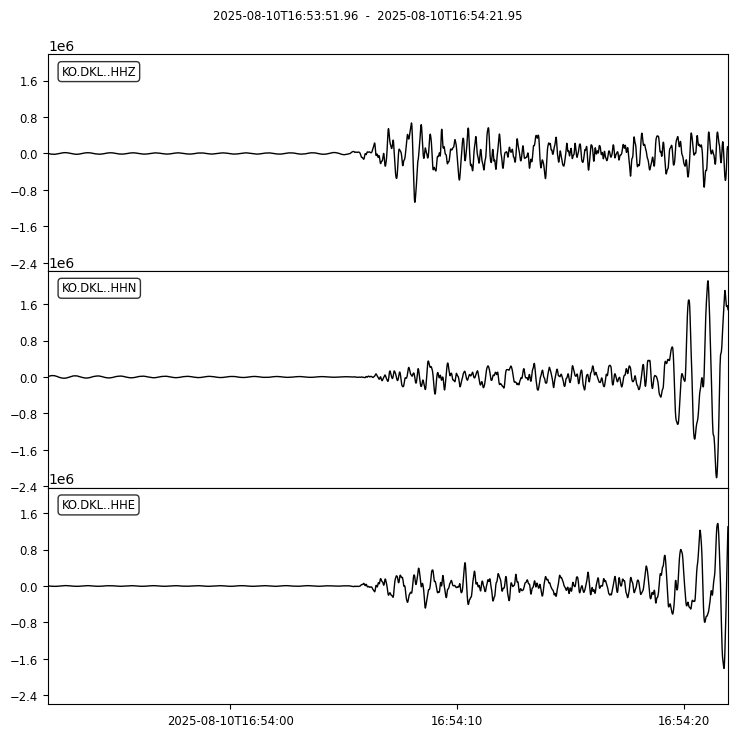

In [10]:
win_eq_pp = win_eq.copy()
for tr in win_eq_pp:
    tr.data = preprocess(tr.data.astype(np.float32), fs)
win_eq_pp.trim(t_eq, t_eq + (WINDOW_SIZE - 1) / fs)

print(f"RECOVAR score = {score_eq:.3f}  (earthquake)")
win_eq_pp.plot();

### Scoring a Noise window

In [11]:
t_noise = obspy.UTCDateTime("2025-08-10T16:58:21.96")

win_noise = st.slice(t_noise - pad, t_noise + WINDOW_SIZE / fs + pad)

zw, nw, ew = [preprocess(win_noise.select(channel=f"*{c}")[0].data.astype(np.float32), fs)[TRIM_SAMPLES:TRIM_SAMPLES + WINDOW_SIZE]
              for c in "ZNE"]

waveform = np.stack([zw, nw, ew], axis=-1)[np.newaxis]   # (1, 3000, 3)
score_noise = float(classifier(waveform)[0])

print(f"Noise window starting {t_noise}")
print(f"RECOVAR earthquake probability: {score_noise:.4f}")

Noise window starting 2025-08-10T16:58:21.960000Z
RECOVAR earthquake probability: 0.0547


RECOVAR score = 0.055  (noise)


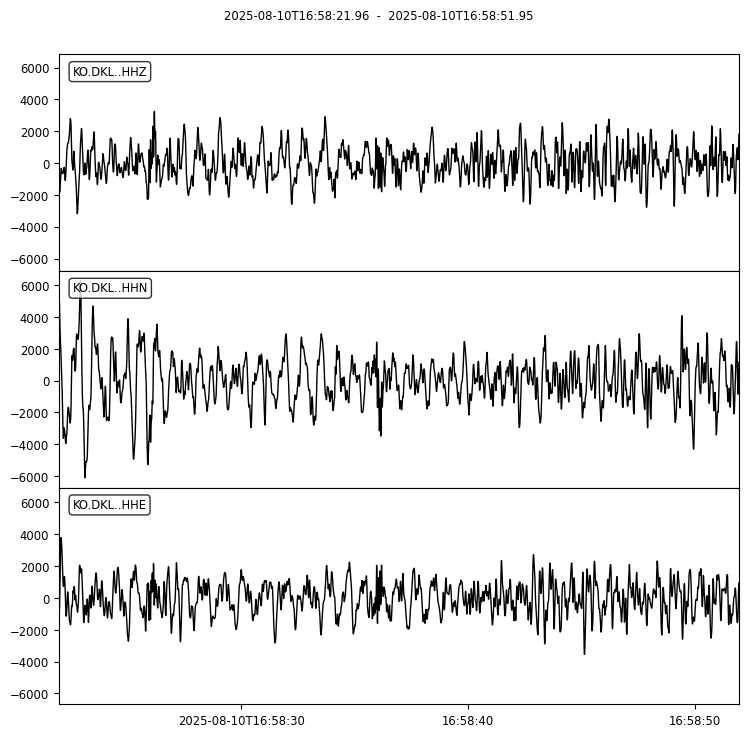

In [12]:
win_noise_pp = win_noise.copy()
for tr in win_noise_pp:
    tr.data = preprocess(tr.data.astype(np.float32), fs)
win_noise_pp.trim(t_noise, t_noise + (WINDOW_SIZE - 1) / fs)

print(f"RECOVAR score = {score_noise:.3f}  (noise)")
win_noise_pp.plot();

## Part 3: Labeled benchmark (ROC / AUC)

Run the same RECOVAR classifier on the labeled test set and plot the ROC
curve. 

It returns an earthquake probability per sample.

Data used here is `data/X_test_1280sample.npy` and `data/Y_test_1280sample.npy`

In [13]:
# Reuse the classifier built in Part 1 on the labeled test set.
TEST_DATA_PATH  = "data/X_test_1280sample.npy"
TEST_LABEL_PATH = "data/Y_test_1280sample.npy"

X_test = np.load(TEST_DATA_PATH)
Y_test = np.load(TEST_LABEL_PATH)
print(f"Test data:  {X_test.shape}")
print(f"Test labels: {Y_test.shape}")

Test data:  (1280, 3000, 3)
Test labels: (1280,)


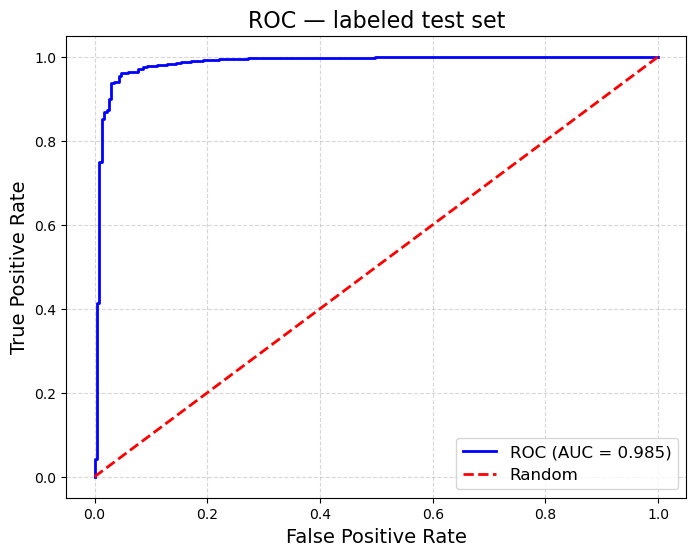

In [14]:
earthquake_scores = classifier(X_test)

fpr, tpr, _ = roc_curve(Y_test, earthquake_scores)
auc = roc_auc_score(Y_test, earthquake_scores)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--", label="Random")
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC — labeled test set", fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()